In [72]:
import os
import argparse
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from torchsummary import summary

In [73]:
DATA_DIR = "dataset"
MODEL_PATH = "output/best_model.pth"
BATCH_SIZE = 32
DATA_LEN = 2500
DECIMATE = 4
INPUT_LENGTH = DATA_LEN // DECIMATE
SEED = 42
CLASS_NAMES = ("2um", "4um", "10um")

torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [74]:
class ParticleDataset(Dataset):
    """Dataset for loading particle signals from .npy files (no filtering or decimation)."""

    def __init__(self, root_dir: Path, class_names: list, transforms=None):
        self.samples = []
        self.labels = []
        self.root_dir = root_dir
        self.class_names = class_names
        self.transforms = transforms

        for class_idx, class_name in enumerate(class_names):
            class_dir = root_dir / class_name
            if not class_dir.exists():
                continue
            for npy_file in class_dir.glob("*.npy"):
                self.samples.append(npy_file)
                self.labels.append(class_idx)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        signal = np.load(self.samples[idx]).astype(np.float32)
        signal = signal[np.newaxis, :]  # Shape: (1, seq_len) for Conv1d
        signal_tensor = torch.from_numpy(signal)

        # Apply transforms sequentially
        if self.transforms is not None:
            for transform in self.transforms:
                signal_tensor = transform(signal_tensor)

        label = self.labels[idx]
        return signal_tensor, label
    
class BandpassFilter:
    """ArithmeticError: Bandpass filter using FFT."""
    def __init__(self, low_cutoff_khz: float, high_cutoff_khz: float, sample_rate_mhz: float):
        self.low_cutoff = low_cutoff_khz * 1000  # Convert kHz to Hz
        self.high_cutoff = high_cutoff_khz * 1000  # Convert kHz to Hz
        self.sample_rate = sample_rate_mhz * 1_000_000  # Convert MHz to Hz

    def __call__(self, signal: torch.Tensor) -> torch.Tensor:
        # Apply bandpass filter using FFT
        fft_signal = torch.fft.fft(signal)
        freqs = torch.fft.fftfreq(signal.size(-1), 1 / self.sample_rate)
        mask = (torch.abs(freqs) >= self.low_cutoff) & (torch.abs(freqs) <= self.high_cutoff)
        filtered_fft = fft_signal * mask
        return torch.fft.ifft(filtered_fft).real

class Decimate:
    """ArithmeticError: Decimation by slicing."""
    def __init__(self, decimate: int):
        self.decimate = decimate

    def __call__(self, signal: torch.Tensor) -> torch.Tensor:
        if self.decimate > 1:
            return signal[..., ::self.decimate]
        return signal

In [75]:
data_dir = Path(DATA_DIR)
if not data_dir.exists():
    raise FileNotFoundError(f"Data directory not found: {data_dir}")

class_names = ["2um", "4um", "10um"]

bandpass = BandpassFilter(low_cutoff_khz=8.0, high_cutoff_khz=40.0, sample_rate_mhz=2.0)
decimate = Decimate(decimate=DECIMATE)

train_dataset = ParticleDataset(data_dir / "train", class_names, transforms=[bandpass, decimate])
test_dataset = ParticleDataset(data_dir / "test", class_names, transforms=[bandpass, decimate])

print(f"Dataset sizes - Train: {len(train_dataset)}, Test: {len(test_dataset)}")
class_counts = {class_name: 0 for class_name in class_names}
for label in train_dataset.labels:
    class_counts[class_names[label]] += 1
print("Training samples per class:", class_counts)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

Dataset sizes - Train: 1209, Test: 302
Training samples per class: {'2um': 403, '4um': 403, '10um': 403}


# Data

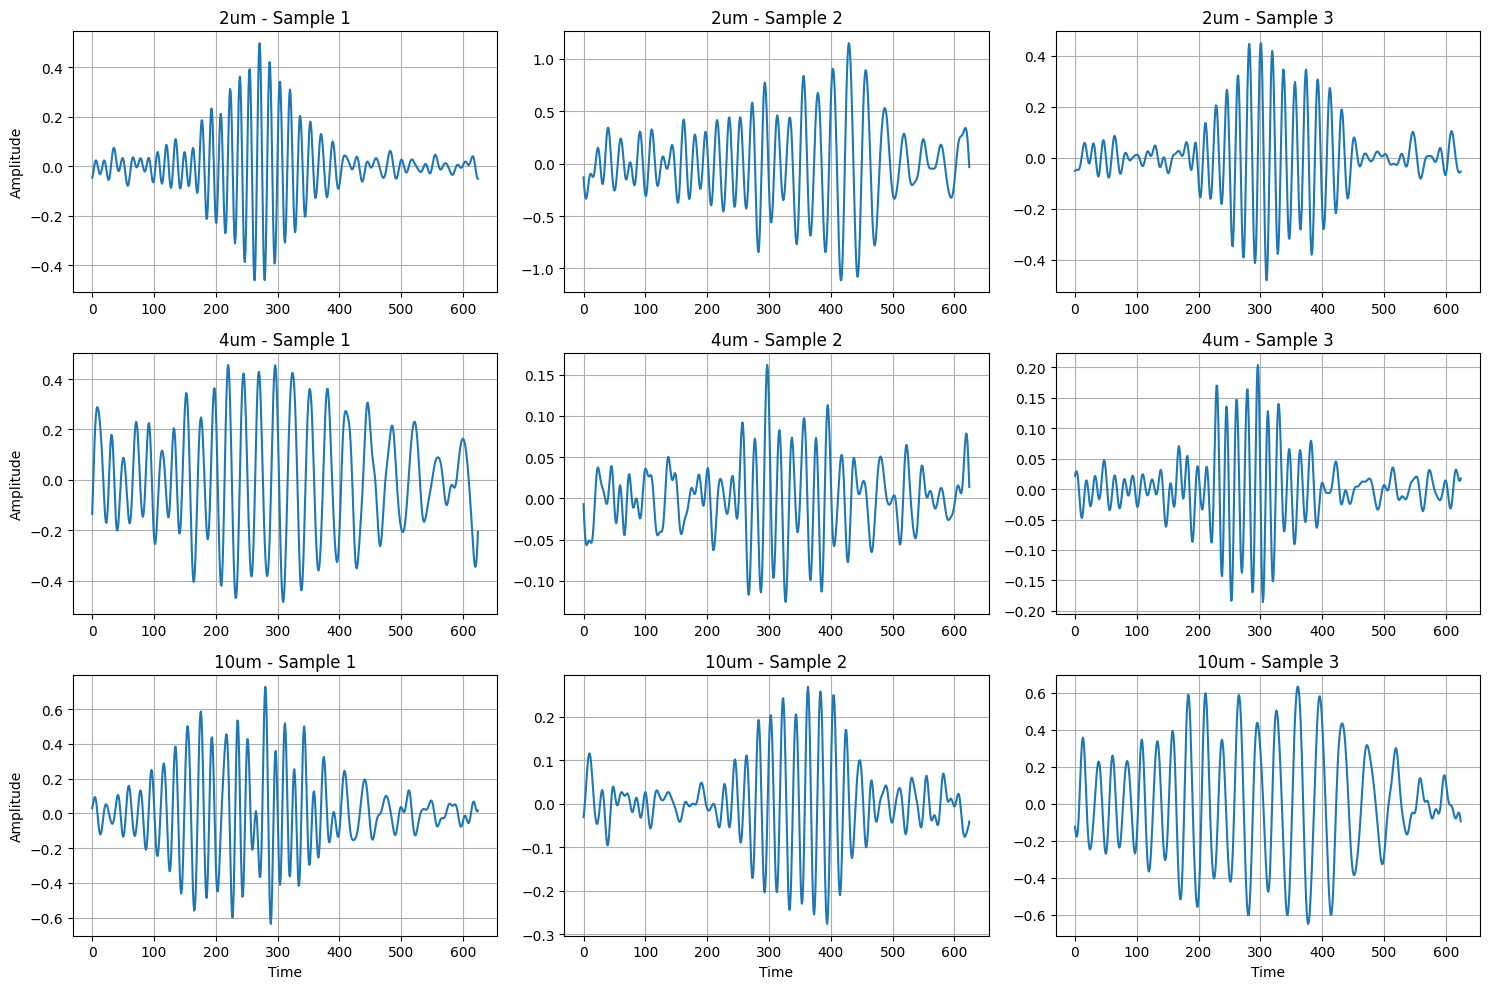

In [76]:
# Select a few samples for visualization
from matplotlib.pyplot import axes
import matplotlib.pyplot as plt

samples_per_class = 3
sample_indices = np.random.choice(len(test_dataset), size=(len(CLASS_NAMES), samples_per_class), replace=False)

fig, axes = plt.subplots(len(CLASS_NAMES), samples_per_class, figsize=(15, 10))

# Plot samples
row_idx = 0
for class_name in CLASS_NAMES:
    for col_idx in range(samples_per_class):
        ax = axes[row_idx, col_idx]
        signal, _ = test_dataset[sample_indices[row_idx, col_idx]]
        signal = signal.squeeze().numpy()  # Remove channel dimension for plotting
        ax.plot(signal)
        ax.set_title(f"{class_name} - Sample {col_idx + 1}")
        ax.grid(True)
        
        if row_idx == 2:  # Last row
            ax.set_xlabel('Time')
        if col_idx == 0:  # First column
            ax.set_ylabel('Amplitude')
    row_idx += 1

plt.tight_layout()
plt.show()

# Model

In [77]:
class Conv1DClassifier(nn.Module):
    """1D Convolutional classifier for particle signals."""
    
    def __init__(self, input_length: int = 250, num_classes: int = 3, dropout: float = 0.2):
        super(Conv1DClassifier, self).__init__()
        
        # Conv1D layers with increasing channels and max pooling to reduce sequence length
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=64, kernel_size=5, padding=2)
        self.bn1 = nn.BatchNorm1d(64)
        self.pool1 = nn.MaxPool1d(kernel_size=2)
        self.drop1 = nn.Dropout(dropout)
        
        self.conv2 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(128)
        self.pool2 = nn.MaxPool1d(kernel_size=2)
        self.drop2 = nn.Dropout(dropout)
        
        self.conv3 = nn.Conv1d(in_channels=128, out_channels=256, kernel_size=5, padding=2)
        self.bn3 = nn.BatchNorm1d(256)
        self.pool3 = nn.MaxPool1d(kernel_size=2)
        self.drop3 = nn.Dropout(dropout)
        
        # Flatten size: 256 channels * (seq_len / 8) width
        flatten_size = 256 * (input_length // 2 // 2 // 2)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(flatten_size, 256)
        self.drop_fc = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, num_classes)
    
    def forward(self, x):
        # Input shape: (batch, seq_len) - 1D signal format
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.drop1(self.pool1(x))
        
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.drop2(self.pool2(x))
        
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.drop3(self.pool3(x))
        
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = self.drop_fc(x)
        x = self.fc2(x)
        return x
    
model = Conv1DClassifier(input_length=INPUT_LENGTH, num_classes=len(CLASS_NAMES)).to(device)
summary(model, input_size=(1, INPUT_LENGTH))

state_dict = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state_dict)
model.eval()

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv1d-1              [-1, 64, 625]             384
       BatchNorm1d-2              [-1, 64, 625]             128
         MaxPool1d-3              [-1, 64, 312]               0
           Dropout-4              [-1, 64, 312]               0
            Conv1d-5             [-1, 128, 312]          41,088
       BatchNorm1d-6             [-1, 128, 312]             256
         MaxPool1d-7             [-1, 128, 156]               0
           Dropout-8             [-1, 128, 156]               0
            Conv1d-9             [-1, 256, 156]         164,096
      BatchNorm1d-10             [-1, 256, 156]             512
        MaxPool1d-11              [-1, 256, 78]               0
          Dropout-12              [-1, 256, 78]               0
          Flatten-13                [-1, 19968]               0
           Linear-14                  [

Conv1DClassifier(
  (conv1): Conv1d(1, 64, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop1): Dropout(p=0.2, inplace=False)
  (conv2): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop2): Dropout(p=0.2, inplace=False)
  (conv3): Conv1d(128, 256, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn3): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop3): Dropout(p=0.2, inplace=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=19968, out_features=256, bias=True)
  (drop

# Do a prediction

In [78]:
def predict(model, signal, device):
    """Predict classes for a given data using the model."""
    model.eval()
    
    with torch.no_grad():
        signal = signal.to(device)
        output = model(signal)
        probs = F.softmax(output, dim=1)
        preds = torch.argmax(probs, dim=1)
        return preds.cpu().numpy()

In [89]:
# Take 3 random samples from the test set and predict their classes
for class_name, samples in zip(CLASS_NAMES, sample_indices):
    for sample in samples:
        signal_tensor, _ = test_dataset[sample]
        signal_tensor = signal_tensor.unsqueeze(0)  # Add batch dimension
        predicted_class = predict(model, signal_tensor, device)
        print(f"Sample: {test_dataset.samples[sample].name}, True Class: {class_name}, Predicted Class: {CLASS_NAMES[predicted_class[0]]}")

Sample: HFocusing_5_10_4um_0_969.npy2280.npy, True Class: 2um, Predicted Class: 4um
Sample: particle_10um_00392.npy342.npy, True Class: 2um, Predicted Class: 10um
Sample: HFocusing_5_10_4um_0_202.npy1671.npy, True Class: 2um, Predicted Class: 4um
Sample: particle_10um_00276.npy253.npy, True Class: 4um, Predicted Class: 10um
Sample: HFocusing_5_10_2um2_0_649.npy3241.npy, True Class: 4um, Predicted Class: 2um
Sample: HFocusing_5_10_2um2_0_2200.npy2819.npy, True Class: 4um, Predicted Class: 2um
Sample: HFocusing_5_10_4um_0_889.npy2205.npy, True Class: 10um, Predicted Class: 4um
Sample: HFocusing_5_10_10um_0_427.npy506.npy, True Class: 10um, Predicted Class: 2um
Sample: particle_10um_00279.npy257.npy, True Class: 10um, Predicted Class: 10um


# Evaluate the model

In [90]:
def evaluate(model, loader, criterion, device):
    """Evaluate model and return loss and accuracy."""
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for signals, labels in loader:
            signals, labels = signals.to(device), labels.to(device)
            outputs = model(signals)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * signals.size(0)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())
    avg_loss = total_loss / len(loader.dataset)
    accuracy = accuracy_score(all_labels, all_preds)
    return avg_loss, accuracy, np.array(all_preds), np.array(all_labels)

criterion = nn.CrossEntropyLoss()
test_loss, test_acc, y_pred, y_true = evaluate(model, test_loader, criterion, device)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

Test Loss: 0.3105, Test Accuracy: 0.9371
